## Optional Exercise 2

> all markdown with `$` is for rendering LaTeX for formulas

Initial $w$ and $w_0$ are $w=(1,0)$ and $w_0 = (-1)$

| y| X | 
|---|---|
| -1 | 1, 1 |
| -1 | 1, 2 |
| -1 | 1, 3 |
| 1 | 3, 1 |
| 1 | 3, 2 |
| 1 | 3, 3 |
| 1 | 100, 1 |

1. Plot the data
2. Plot the hyperplane given by w and w0 - does this hyperplane separate the two classes?
3. Calculate least squares objective
4. Calculate hinge loss

* Blue Line $u = (1,0)$, $u_0=-2$ 
* Red Line $v = (1,0)$, $v_0=-4$ 

In [ ]:
# install dependencies for graph plotting
%pip install matplotlib

### 1. Plot the data & 2. Plot the Hyperplane

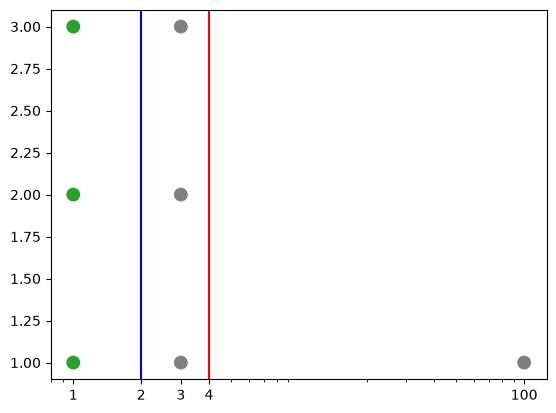

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

X = [[1, 1], [1, 2], [1, 3], [3, 1], [3, 2], [3, 3], [100, 1]]
y = [-1, -1, -1, 1, 1, 1, 1]

u = [1, 0]
u0 = -2

v = [1, 0]
v0 = -4

# plot data
# unpack to make it x and y for plotting
px, py = zip(*X)

colors = ["tab:green" if label == -1 else "tab:grey" for label in y]

plt.scatter(px, py, c=colors, s=80)
plt.xscale("log")

# hyperplanes
plt.axvline(-u0 / u[0], color="blue")
plt.axvline(-v0 / v[0], color="red")

# just so the log scale show up as reasonable
ax = plt.gca()
ax.set_xticks([1, 2, 3, 4, 100])
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.show()

### 3. Least Square Objective

Formula for least square objective.

$L = \sum_{i=0}^{n-1} (w^Tx_i + w_0 - y_i)^2$

#### Least squares loss of Blue Line $(u)$

In [43]:
lso_blue = []
sigma_blue = 0
# traditional looping! we know length of X and y are same.

print("   x    |    wT    | wTx |  w0  |  yi   ")
for i in range(len(X)):
    dot_product = 0
    row = X[i]
    for j in range(len(row)):
        dot_product += row[j] * u[j]

    sum = dot_product + u0 - y[i]
    lso_blue.append(sum)
    sigma_blue = sigma_blue + (sum * sum)
    print(row, " | ", u, " | ", dot_product, " | ", u0, " | ", y[i])

print("--------------------------")
print("Individual Values:", lso_blue)
print("Least Square Loss for Blue Line: ", sigma_blue)

   x    |    wT    | wTx |  w0  |  yi   
[1, 1]  |  [1, 0]  |  1  |  -2  |  -1
[1, 2]  |  [1, 0]  |  1  |  -2  |  -1
[1, 3]  |  [1, 0]  |  1  |  -2  |  -1
[3, 1]  |  [1, 0]  |  3  |  -2  |  1
[3, 2]  |  [1, 0]  |  3  |  -2  |  1
[3, 3]  |  [1, 0]  |  3  |  -2  |  1
[100, 1]  |  [1, 0]  |  100  |  -2  |  1
--------------------------
Individual Values: [0, 0, 0, 0, 0, 0, 97]
Least Square Loss for Blue Line:  9409


#### Least squares loss of Red Line $(v)$

In [44]:
lso_red = []
sigma_red = 0
# traditional looping! we know length of X and y are same.

print("   x    |    wT    | wTx |  w0  |  yi   ")
for i in range(len(X)):
    dot_product = 0
    row = X[i]
    for j in range(len(row)):
        dot_product += row[j] * v[j]

    sum = dot_product + v0 - y[i]
    lso_red.append(sum)
    sigma_red = sigma_red + (sum * sum)
    print(row, " | ", v, " | ", dot_product, " | ", v0, " | ", y[i])

print("--------------------------")
print("Individual Values:", lso_red)
print("Least Square Loss for Red Line: ", sigma_red)

   x    |    wT    | wTx |  w0  |  yi   
[1, 1]  |  [1, 0]  |  1  |  -4  |  -1
[1, 2]  |  [1, 0]  |  1  |  -4  |  -1
[1, 3]  |  [1, 0]  |  1  |  -4  |  -1
[3, 1]  |  [1, 0]  |  3  |  -4  |  1
[3, 2]  |  [1, 0]  |  3  |  -4  |  1
[3, 3]  |  [1, 0]  |  3  |  -4  |  1
[100, 1]  |  [1, 0]  |  100  |  -4  |  1
--------------------------
Individual Values: [-2, -2, -2, -2, -2, -2, 95]
Least Square Loss for Red Line:  9049


### 4. Hinge Loss 

$H_L = \sum_{i=0}^{n-1} max(0, 1- y_i(w^Tx_i+w_0))$

#### Hinge Loss of Blue Line $(u)$



In [45]:
hl_blue = []
hl_sigma_blue = 0

print("   x    |    wT    | wTx |  w0  |  yi   ")
for i in range(len(X)):
    dot_product = 0
    row = X[i]

    for j in range(len(row)):
        dot_product += row[j] * u[j]

    val = max(0, 1 - y[i] * (dot_product + u0))
    print(row, " | ", u, " | ", dot_product, " | ", u0, " | ", y[i])
    hl_blue.append(val)
    hl_sigma_blue = hl_sigma_blue + val

print("--------------------------")
print("Individual Values:", hl_blue)
print("Hinge Loss for Blue Line: ", hl_sigma_blue)

   x    |    wT    | wTx |  w0  |  yi   
[1, 1]  |  [1, 0]  |  1  |  -2  |  -1
[1, 2]  |  [1, 0]  |  1  |  -2  |  -1
[1, 3]  |  [1, 0]  |  1  |  -2  |  -1
[3, 1]  |  [1, 0]  |  3  |  -2  |  1
[3, 2]  |  [1, 0]  |  3  |  -2  |  1
[3, 3]  |  [1, 0]  |  3  |  -2  |  1
[100, 1]  |  [1, 0]  |  100  |  -2  |  1
--------------------------
Individual Values: [0, 0, 0, 0, 0, 0, 0]
Hinge Loss for Blue Line:  0


#### Hinge Loss of Red Line $(v)$

In [46]:
hl_red = []
hl_sigma_red = 0

print("   x    |    wT    | wTx |  w0  |  yi   ")
for i in range(len(X)):
    dot_product = 0
    row = X[i]

    for j in range(len(row)):
        dot_product += row[j] * v[j]

    val = max(0, 1 - y[i] * (dot_product + v0))
    print(row, " | ", v, " | ", dot_product, " | ", v0, " | ", y[i])
    hl_red.append(val)
    hl_sigma_red = hl_sigma_red + val

print("--------------------------")
print("Individual Values:", hl_red)
print("Hinge Loss for Blue Line: ", hl_sigma_red)

   x    |    wT    | wTx |  w0  |  yi   
[1, 1]  |  [1, 0]  |  1  |  -4  |  -1
[1, 2]  |  [1, 0]  |  1  |  -4  |  -1
[1, 3]  |  [1, 0]  |  1  |  -4  |  -1
[3, 1]  |  [1, 0]  |  3  |  -4  |  1
[3, 2]  |  [1, 0]  |  3  |  -4  |  1
[3, 3]  |  [1, 0]  |  3  |  -4  |  1
[100, 1]  |  [1, 0]  |  100  |  -4  |  1
--------------------------
Individual Values: [0, 0, 0, 2, 2, 2, 0]
Hinge Loss for Blue Line:  6


In [47]:
print("                  |  Blue Line  |  Red Line  ")
print("------------------+------------ +----------- ")
print("Least Square Loss |   ", sigma_blue, "    |  ", sigma_red)
print("Hinge Loss        |   ", hl_sigma_blue, "       |  ", hl_sigma_red)

                  |  Blue Line  |  Red Line  
------------------+------------ +----------- 
Least Square Loss |    9409     |   9049
Hinge Loss        |    0        |   6


### Compare results for Least Square Loss vs Hinge Loss

| Loss Type |  Blue Line  |  Red Line  |
| --- | --- | --- | 
| Least Square Loss |    9409     |   9049 |
| Hinge Loss        |    0        |   6 |